In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("results/results.csv")
df['asr_pct'] = df['asr'] * 100
df_ab = df[df['exp_type'].isin(['A', 'B'])].copy()

In [3]:
colors  = {'FGSM': '#E74C3C', 'PGD': '#2980B9'}
markers = {'FGSM': 'o', 'PGD': 's'}
text_positions = {'FGSM': (0, 8), 'PGD': (0, 15)}
text_va        = {'FGSM': 'bottom', 'PGD': 'top'}

In [4]:
def plot_dataset(dataset_name, save_fname):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    subplot_configs = [('A', 'Targeted'), ('B', 'Untargeted')]

    for ax, (exp_type, label) in zip(axes, subplot_configs):
        subset = df_ab[
            (df_ab['dataset'] == dataset_name) &
            (df_ab['exp_type'] == exp_type)
        ]

        for attack_name in sorted(subset['attack'].unique()):
            method = 'FGSM' if 'FGSM' in attack_name else 'PGD'
            data = subset[subset['attack'] == attack_name].sort_values('eps')

            ax.plot(data['eps'], data['asr_pct'],
                    label=method,
                    color=colors[method],
                    marker=markers[method],
                    linewidth=2,
                    markersize=6)

            for _, row in data.iterrows():
                ax.annotate(f"{row['asr_pct']:.1f}%",
                            xy=(row['eps'], row['asr_pct']),
                            xytext=text_positions[method],
                            textcoords='offset points',
                            ha='center',
                            va=text_va[method],
                            fontsize=7.5,
                            color=colors[method])

        ax.set_title(f'{dataset_name} — {label}', fontsize=13,
                     fontweight='bold', pad=15)
        ax.set_xlabel('Epsilon (ε)', fontsize=11)
        ax.set_ylabel('ASR (%)', fontsize=11)
        ax.set_ylim(-5, 115)
        ax.set_xticks([0.05, 0.1, 0.2, 0.3, 0.4, 0.5])
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"results/{save_fname}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"저장 완료: results/{save_fname}")

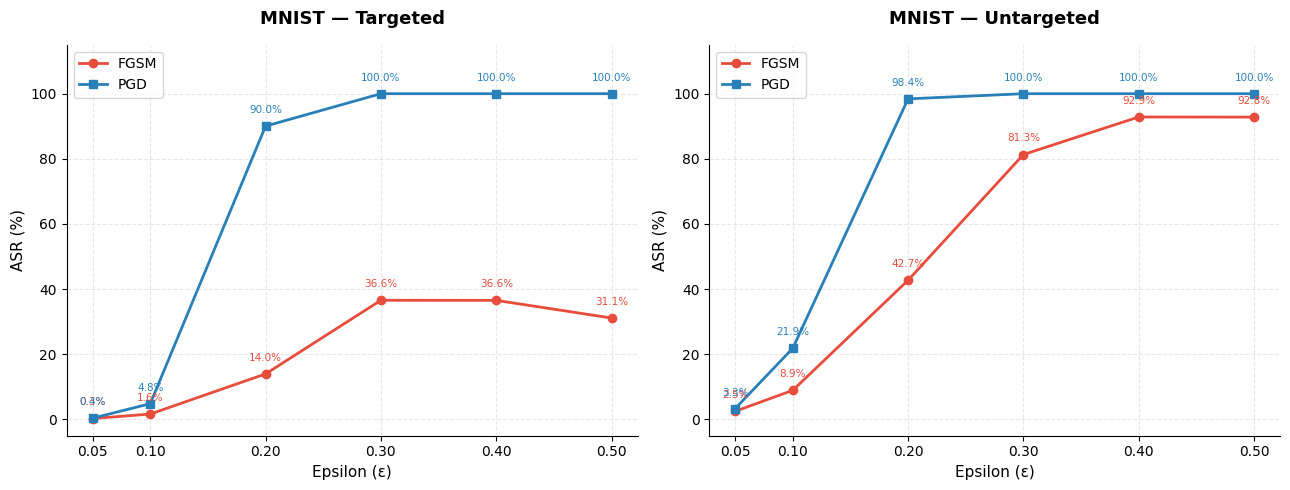

저장 완료: results/asr_mnist.png


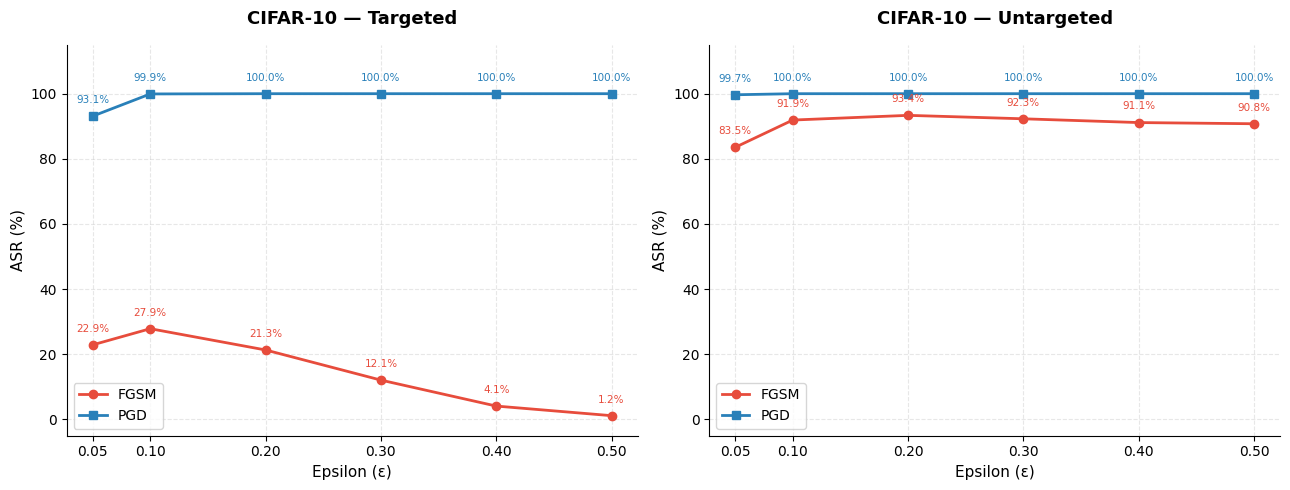

저장 완료: results/asr_cifar10.png


In [5]:
plot_dataset('MNIST',    'asr_mnist.png')
plot_dataset('CIFAR-10', 'asr_cifar10.png')

In [6]:
pivot_A = df[df['exp_type'] == 'A'].pivot_table(
    index=['dataset', 'attack'], columns='eps', values='asr_pct'
).round(2)
print("\n[실험 A] Pivot Table")
pivot_A


[실험 A] Pivot Table


eps                      0.05   0.10    0.20    0.30    0.40    0.50
dataset  attack                                                     
CIFAR-10 FGSM_Targeted  22.89  27.86   21.32   12.07    4.10    1.16
         PGD_Targeted   93.10  99.92  100.00  100.00  100.00  100.00
MNIST    FGSM_Targeted   0.28   1.65   13.98   36.58   36.55   31.14
         PGD_Targeted    0.38   4.84   90.05  100.00  100.00  100.00

In [8]:
pivot_B = df[df['exp_type'] == 'B'].pivot_table(
    index=['dataset', 'attack'], columns='eps', values='asr_pct'
).round(2)
print("\n[실험 B] Pivot Table (Untargeted)")
pivot_B


[실험 B] Pivot Table (Untargeted)


eps                        0.05    0.10    0.20    0.30    0.40    0.50
dataset  attack                                                        
CIFAR-10 FGSM_Untargeted  83.52   91.91   93.35   92.29   91.14   90.77
         PGD_Untargeted   99.67  100.00  100.00  100.00  100.00  100.00
MNIST    FGSM_Untargeted   2.49    8.94   42.73   81.32   92.86   92.80
         PGD_Untargeted    3.31   21.85   98.41  100.00  100.00  100.00

In [7]:
pivot_C = df[df['exp_type'] == 'C'].pivot_table(
    index=['dataset', 'attack'], columns='target_class', values='asr_pct'
).round(2)
print("\n[실험 C] Pivot Table")
pivot_C


[실험 C] Pivot Table


target_class               0.0     1.0     2.0     3.0     4.0     5.0  \
dataset  attack                                                          
CIFAR-10 FGSM_Targeted   15.25    8.90   54.80   32.10   41.65    7.08   
         PGD_Targeted   100.00   99.97  100.00  100.00  100.00  100.00   
MNIST    FGSM_Targeted    5.86   22.93   81.84   57.64   20.84   37.85   
         PGD_Targeted    99.57  100.00  100.00  100.00   99.90  100.00   

target_class               6.0     7.0     8.0     9.0  
dataset  attack                                         
CIFAR-10 FGSM_Targeted   60.09    4.79   12.07   12.17  
         PGD_Targeted   100.00  100.00  100.00  100.00  
MNIST    FGSM_Targeted   12.91    9.80   36.58   18.29  
         PGD_Targeted    99.97   99.98  100.00   99.75

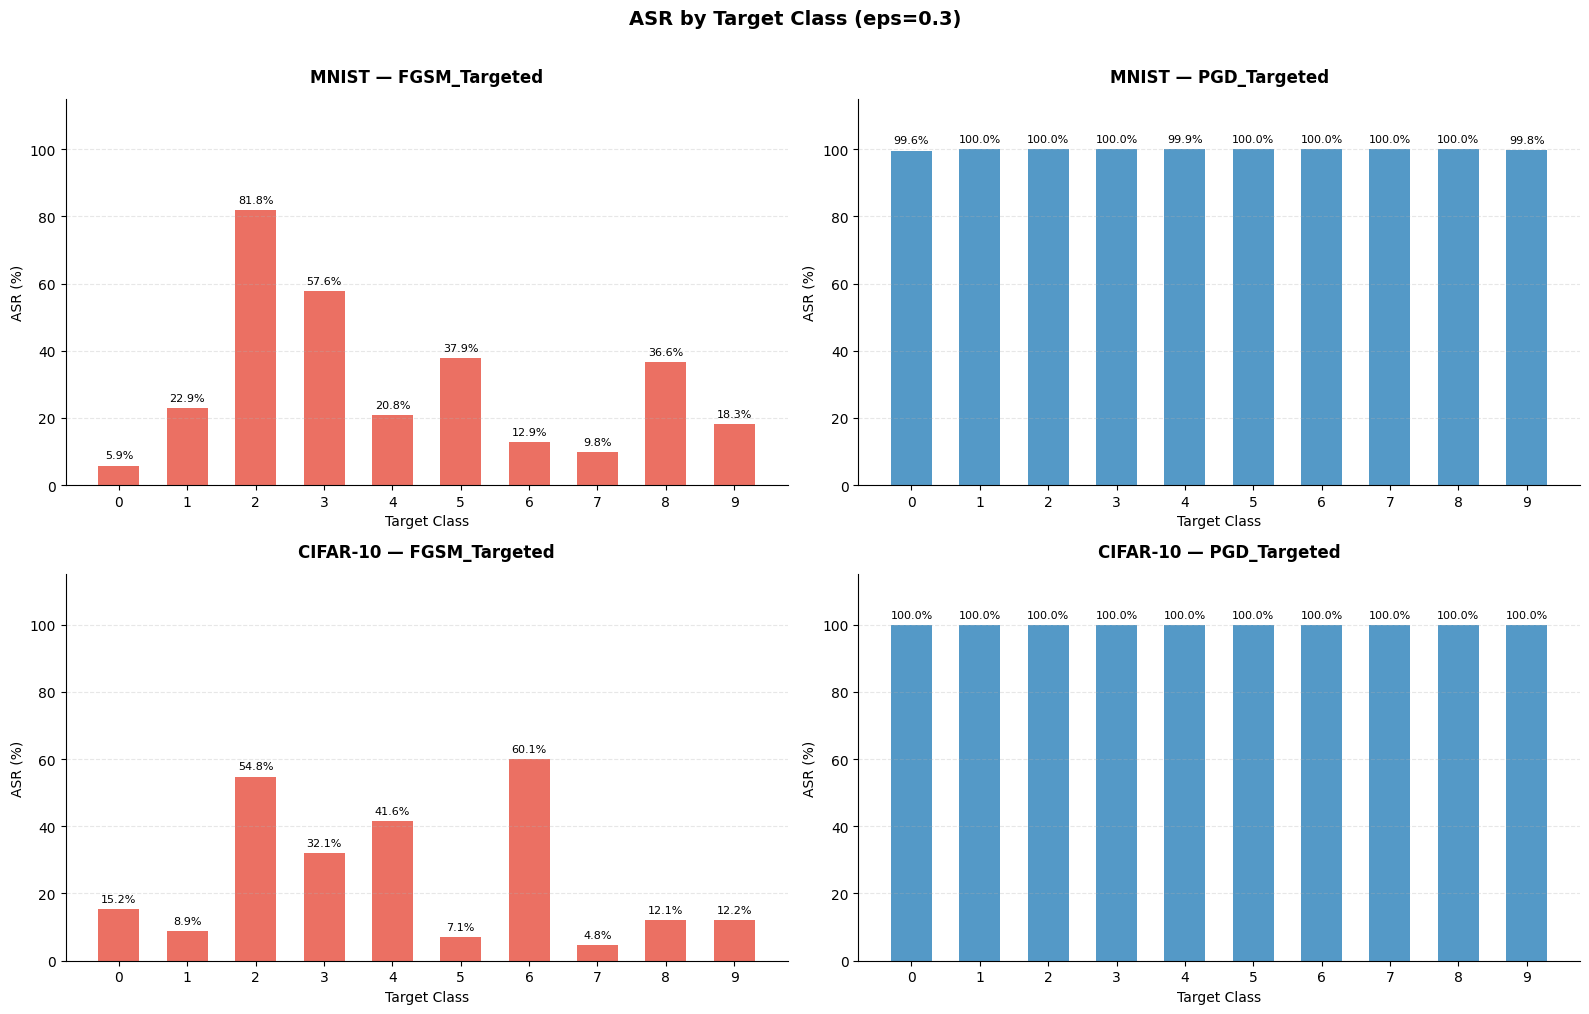

In [12]:
# dataset × attack 조합별로 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

order = [
    ('MNIST',    'FGSM_Targeted'),
    ('MNIST',    'PGD_Targeted'),
    ('CIFAR-10', 'FGSM_Targeted'),
    ('CIFAR-10', 'PGD_Targeted'),
]


for ax, idx in zip(axes, order):
    row = pivot_C.loc[idx]
    dataset, attack = idx
    method = 'FGSM' if 'FGSM' in attack else 'PGD'
    color  = '#E74C3C' if method == 'FGSM' else '#2980B9'

    classes = row.index.astype(int)
    values  = row.values

    bars = ax.bar(classes, values, color=color, alpha=0.8, width=0.6)

    # 데이터 라벨
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f"{val:.1f}%",
                ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{dataset} — {attack}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Target Class', fontsize=10)
    ax.set_ylabel('ASR (%)', fontsize=10)
    ax.set_xticks(classes)
    ax.set_ylim(0, 115)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('ASR by Target Class (eps=0.3)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("results/asr_per_class.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import pandas as pd

df = pd.read_csv("results/results.csv")
df['asr_pct'] = (df['asr'] * 100).round(2)

# 실험 A (Targeted), B (Untargeted) 합치기
df_ab = df[df['exp_type'].isin(['A', 'B'])].copy()

# attack에서 method(FGSM/PGD)와 type(Targeted/Untargeted) 분리
df_ab['method'] = df_ab['attack'].apply(lambda x: 'FGSM' if 'FGSM' in x else 'PGD')
df_ab['type']   = df_ab['attack'].apply(lambda x: 'Targeted' if 'Targeted' in x else 'Untargeted')

# pivot: 행=(dataset, eps), 열=(type, method)
pivot = df_ab.pivot_table(
    index=['dataset', 'eps'],
    columns=['type', 'method'],
    values='asr_pct'
).round(2)

# 열 순서 정렬: Targeted(FGSM, PGD) → Untargeted(FGSM, PGD)
pivot = pivot[['Targeted', 'Untargeted']]

# 행 순서: MNIST → CIFAR-10
pivot = pivot.reindex(['MNIST', 'CIFAR-10'], level='dataset')

print(pivot.to_string())


type          Targeted         Untargeted        
method            FGSM     PGD       FGSM     PGD
dataset  eps                                     
MNIST    0.05     0.28    0.38       2.49    3.31
         0.10     1.65    4.84       8.94   21.85
         0.20    13.98   90.05      42.73   98.41
         0.30    36.58  100.00      81.32  100.00
         0.40    36.55  100.00      92.86  100.00
         0.50    31.14  100.00      92.80  100.00
CIFAR-10 0.05    22.89   93.10      83.52   99.67
         0.10    27.86   99.92      91.91  100.00
         0.20    21.32  100.00      93.35  100.00
         0.30    12.07  100.00      92.29  100.00
         0.40     4.10  100.00      91.14  100.00
         0.50     1.16  100.00      90.77  100.00
